<a href="https://colab.research.google.com/github/Akshansh-Sinha/AiVoiceChartBot/blob/main/RelianceMarketRegimeDiscovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance


In [2]:
import pandas as pd
import yfinance as yf
import numpy as np

In [3]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01",
    interval="1d",
    auto_adjust=False,
    progress=False
)
CSV_data = df.to_csv("reliance_raw_ohlcv.csv")



In [4]:
df.columns = df.columns.get_level_values(0)


In [5]:
df.dtypes



,0
Price,
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [6]:
# df.columns.name = None
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [7]:
df.head()


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,189.999802,202.959000,203.896194,201.987518,202.593277,2963643
2015-01-02,189.496948,202.421829,204.821960,202.136108,203.004715,7331366
2015-01-05,187.421249,200.204575,203.644760,199.804550,202.296112,10103941
2015-01-06,178.915207,191.118393,199.553116,190.181198,198.867371,18627980
2015-01-07,182.809814,195.278610,196.307236,191.324127,191.346985,20720312


In [8]:

df.shape

(2467, 6)

In [9]:
df.isnull().sum()

,0
Price,
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [10]:
df.index.duplicated().sum()


np.int64(0)

In [11]:
df_copy = df.copy()

## Feature Engineering Overview

Raw OHLCV data represents price levels rather than market behavior.  
To identify market regimes, we transform the data into stationary behavioral features that capture **direction**, **risk**, and **participation**.

---

### **Log Return**

$$
r_t = \ln\left(\frac{AdjClose_t}{AdjClose_{t-1}}\right)
$$

**Purpose:**  
Captures the direction and magnitude of daily price movement while removing long-term trends.

---

### **Rolling Volatility**

$$
\sigma_t = \text{std}(r_{t-k:t})
$$

**Purpose:**  
Measures time-varying risk and uncertainty, distinguishing calm periods from stressed market conditions.

---

### **Normalized Volume**

$$
Z_t = \frac{Volume_t - \mu_{t-k}}{\sigma_{t-k}}
$$

**Purpose:**  
Represents relative trading activity, highlighting unusually high or low market participation.

---

## Impact

These features convert raw market data into interpretable signals describing **direction**, **risk**, and **participation**, enabling effective probabilistic clustering and market regime discovery.


In [12]:
df_copy['log return'] = np.log(df_copy['Adj Close'] / df_copy['Adj Close'].shift(1))

In [13]:
df_copy['log return'].describe()

,log return
count,2466.000000
mean,0.000751
std,0.017467
min,-0.141033
25%,-0.008648
50%,0.000708
75%,0.009919
max,0.137307


<Axes: >

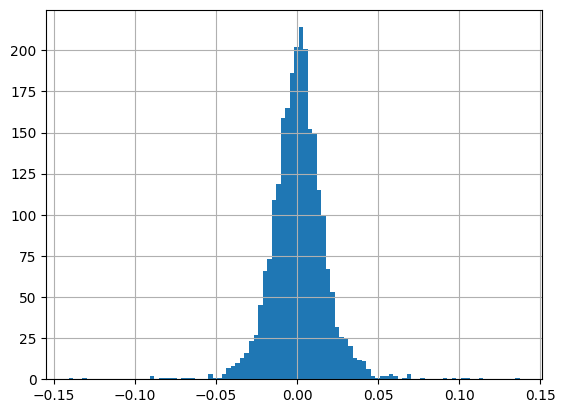

In [14]:
df_copy['log return'].hist(bins=100)

In [15]:
VOL_WINDOW = 14
df_copy['volatility'] = df_copy['log return'].rolling(VOL_WINDOW).std()

In [16]:
df_copy['volatility'].describe()

,volatility
count,2453.000000
mean,0.015748
std,0.007567
min,0.005522
25%,0.011540
50%,0.014320
75%,0.017571
max,0.083371


<Axes: xlabel='Date'>

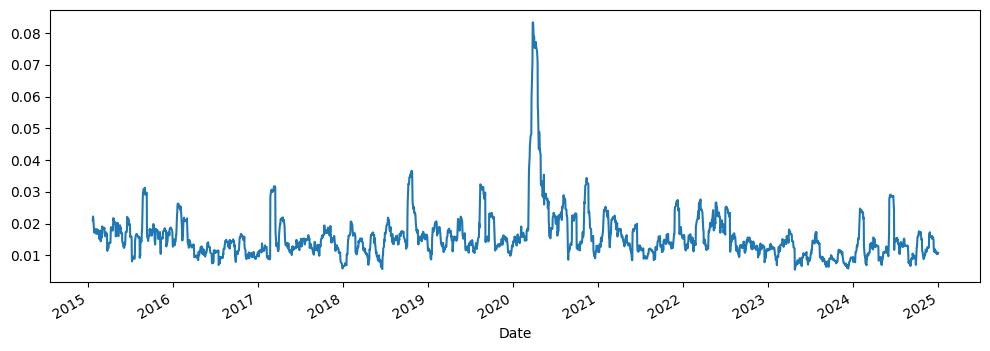

In [17]:
df_copy['volatility'].plot(figsize=(12,4))


In [18]:
VOLZ_WINDOW = 20

vol_mean = df_copy['Volume'].rolling(VOLZ_WINDOW).mean()
vol_std  = df_copy['Volume'].rolling(VOLZ_WINDOW).std()

df_copy['volume_z'] = (df_copy['Volume'] - vol_mean) / vol_std


In [19]:
df_copy['volume_z'].describe()


,volume_z
count,2448.000000
mean,-0.006662
std,1.023685
min,-2.277706
25%,-0.694871
50%,-0.260282
75%,0.432416
max,4.190604


<Axes: xlabel='Date'>

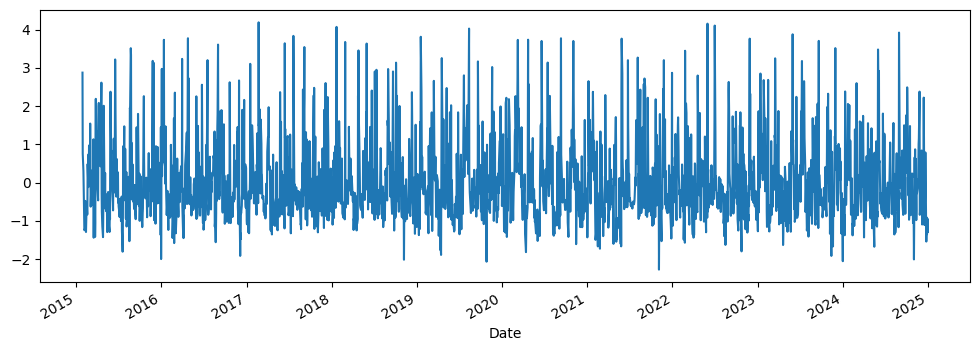

In [20]:
df_copy['volume_z'].plot(figsize=(12,4))


In [21]:
df_copy['volume_z'].abs().sort_values(ascending=False).head(5)


,volume_z
Date,
2017-02-22,4.190604
2022-05-31,4.155990
2022-07-01,4.105501
2018-01-22,4.071523
2019-08-13,4.026795


In [22]:
features = df_copy[['log return', 'volatility', 'volume_z']].dropna()

features.shape
features.isnull().sum()


,0
Price,
log return,0
volatility,0
volume_z,0


In [23]:
features.describe()


Price,log return,volatility,volume_z
count,2448.000000,2448.000000,2448.000000
mean,0.000748,0.015739,-0.006662
std,0.017452,0.007571,1.023685
min,-0.141033,0.005522,-2.277706
25%,-0.008631,0.011527,-0.694871
50%,0.000672,0.014298,-0.260282
75%,0.009900,0.017552,0.432416
max,0.137307,0.083371,4.190604


In [24]:
features.corr()


Price,log return,volatility,volume_z
Price,,,
log return,1.000000,0.054526,0.073942
volatility,0.054526,1.000000,0.055541
volume_z,0.073942,0.055541,1.000000


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

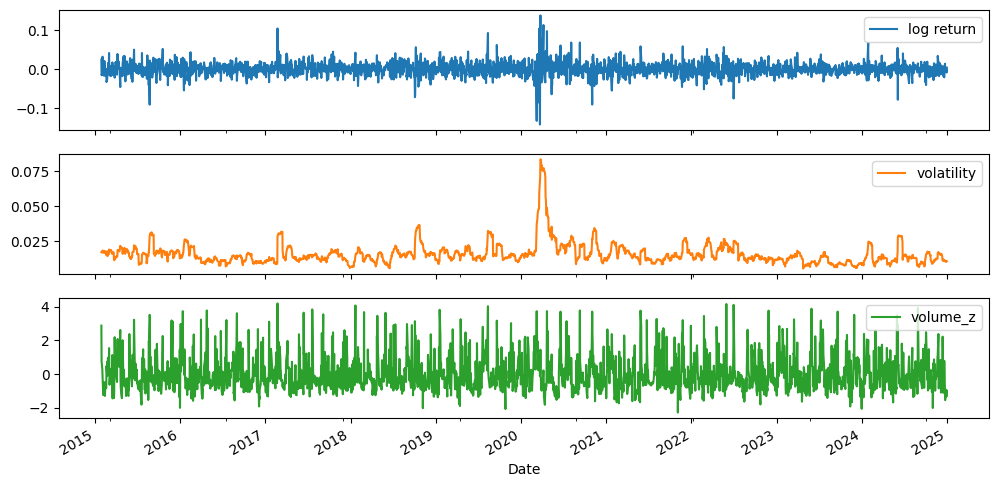

In [25]:
features.plot(subplots=True, figsize=(12,6))


In [26]:
features.abs().max()


,0
Price,
log return,0.141033
volatility,0.083371
volume_z,4.190604


In [27]:
features.head()

Price,log return,volatility,volume_z
Date,,,
2015-01-29,0.024562,0.017112,2.875085
2015-01-30,-0.015342,0.017551,0.754993
2015-02-02,-0.007898,0.017311,0.298310
2015-02-03,0.032024,0.018299,-0.133352
2015-02-04,-0.009430,0.018274,-0.612413


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


In [29]:
features_scaled = pd.DataFrame(
    features_scaled,
    index=features.index,
    columns=features.columns
)


In [30]:
features_scaled.describe()


Price,log return,volatility,volume_z
count,2448.000000,2.448000e+03,2.448000e+03
mean,0.000000,6.966105e-17,3.374207e-17
std,1.000204,1.000204e+00,1.000204e+00
min,-8.125794,-1.349721e+00,-2.218953e+00
25%,-0.537502,-5.564937e-01,-6.724230e-01
50%,-0.004327,-1.904257e-01,-2.478020e-01
75%,0.524555,2.395240e-01,4.290073e-01
max,7.826557,8.934627e+00,4.100994e+00


In [31]:
from sklearn.mixture import GaussianMixture
import numpy as np

X = features_scaled.values

bic_scores = []
k_range = range(1, 8)

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))


Figure 1: Bayesian Information Criterion (BIC) for different numbers of Gaussian Mixture components. The curve shows a clear elbow at K = 3, indicating an optimal balance between model fit and complexity.


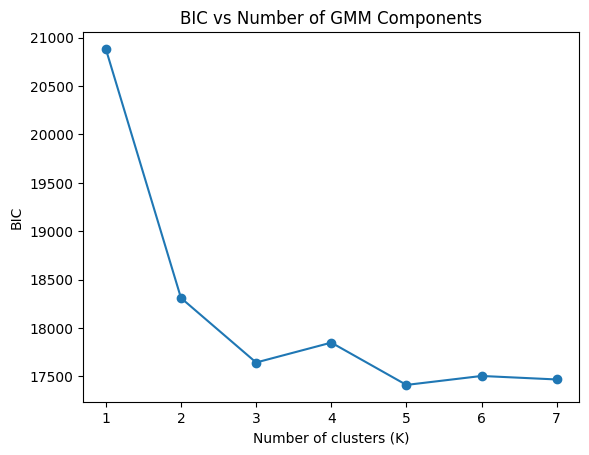

In [32]:
import matplotlib.pyplot as plt

plt.plot(k_range, bic_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("BIC")
plt.title("BIC vs Number of GMM Components")
plt.show()


In [33]:
K = 3

gmm = GaussianMixture(
    n_components=K,
    covariance_type='full',
    random_state=42
)

gmm.fit(X)


GaussianMixture(n_components=3, random_state=42)

In [34]:
features_scaled['regime'] = gmm.predict(X)


In [35]:
probs = gmm.predict_proba(X)

for i in range(K):
    features_scaled[f'regime_{i}_prob'] = probs[:, i]


In [36]:
features_scaled['regime'].value_counts(normalize=True)


,proportion
regime,
1,0.628676
2,0.340686
0,0.030637


In [37]:
features_scaled.groupby('regime').mean()


Price,log return,volatility,volume_z,regime_0_prob,regime_1_prob,regime_2_prob
regime,,,,,,
0,0.161104,3.096015,1.823188,0.908156,6.690349e-10,0.091844
1,-0.027861,-0.370949,-0.450331,0.000010,9.181261e-01,0.081864
2,0.036924,0.406102,0.667051,0.018040,1.013389e-01,0.880621


<Axes: xlabel='Date'>

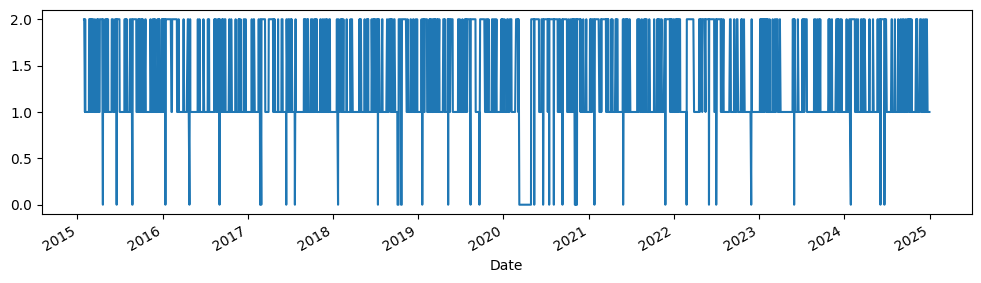

In [38]:
features_scaled['regime'].plot(figsize=(12,3))


Figure 2: Rolling volatility over time, colored by GMM-assigned market regimes. The stress regime aligns with extreme volatility spikes, while normal and active regimes occupy lower risk bands.


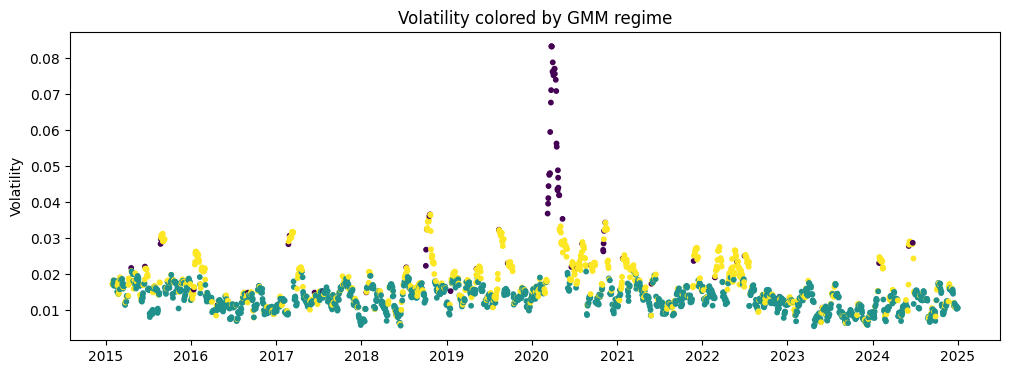

In [39]:
plt.figure(figsize=(12,4))
plt.scatter(
    features_scaled.index,
    features['volatility'],
    c=features_scaled['regime'],
    cmap='viridis',
    s=10
)
plt.ylabel("Volatility")
plt.title("Volatility colored by GMM regime")
plt.show()


In [40]:
# X is the standardized feature matrix
X = features_scaled[['log return', 'volatility', 'volume_z']].values

# Log-likelihood of each point
log_likelihood = gmm.score_samples(X)

features_scaled['log_likelihood'] = log_likelihood


In [41]:
features_scaled['log_likelihood'].describe()


,log_likelihood
count,2448.000000
mean,-3.557341
std,1.833104
min,-15.237977
25%,-4.424378
50%,-3.242511
75%,-2.140720
max,-1.221578


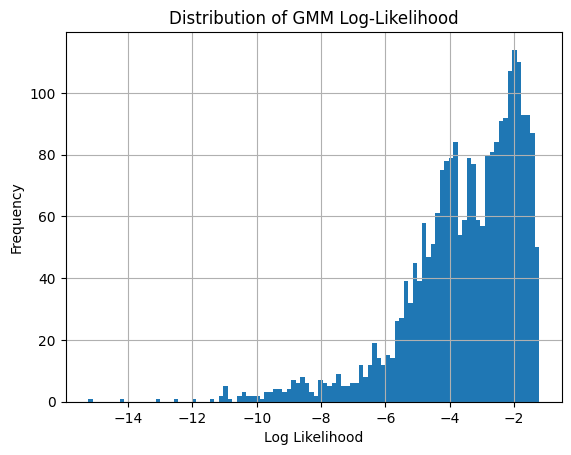

In [42]:
features_scaled['log_likelihood'].hist(bins=100)
plt.xlabel("Log Likelihood")
plt.ylabel("Frequency")
plt.title("Distribution of GMM Log-Likelihood")
plt.show()


In [43]:
features_scaled['log_likelihood'].skew()


np.float64(-1.5155331230321003)

In [44]:
threshold = features_scaled['log_likelihood'].quantile(0.01)


In [45]:
features_scaled['anomaly'] = (
    features_scaled['log_likelihood'] < threshold
)


In [46]:
features_scaled['anomaly'].value_counts(normalize=True)


,proportion
anomaly,
False,0.989788
True,0.010212


Figure 3: Detected anomalous trading days overlaid on rolling volatility. Anomalies cluster during periods of systemic stress, particularly during the March–April 2020 market crisis.


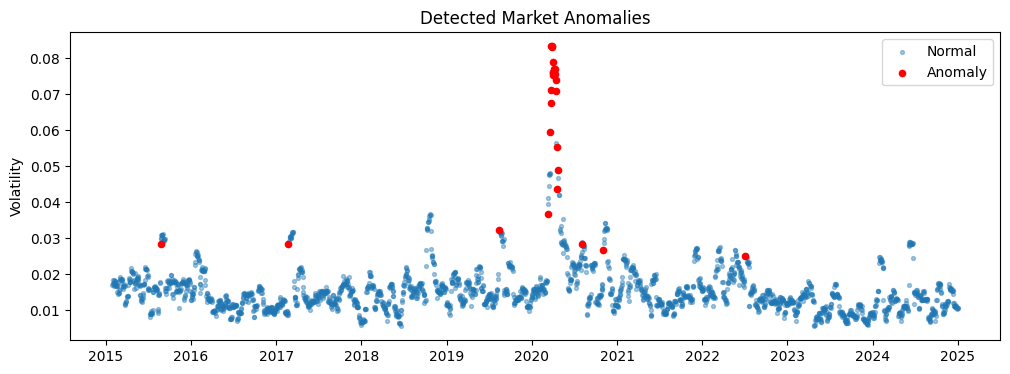

In [47]:
plt.figure(figsize=(12,4))

# Normal points
plt.scatter(
    features_scaled.index[~features_scaled['anomaly']],
    features.loc[~features_scaled['anomaly'], 'volatility'],
    s=8,
    alpha=0.4,
    label='Normal'
)

# Anomalies
plt.scatter(
    features_scaled.index[features_scaled['anomaly']],
    features.loc[features_scaled['anomaly'], 'volatility'],
    color='red',
    s=20,
    label='Anomaly'
)

plt.ylabel("Volatility")
plt.title("Detected Market Anomalies")
plt.legend()
plt.show()


In [48]:
pd.crosstab(
    features_scaled['regime'],
    features_scaled['anomaly'],
    normalize='index'
)


anomaly,False,True
regime,,
0,0.666667,0.333333
1,1.000000,0.000000
2,1.000000,0.000000


In [49]:
anomaly_days = features_scaled[features_scaled['anomaly']].copy()

# Sort by severity (most anomalous first)
anomaly_days = anomaly_days.sort_values('log_likelihood')

anomaly_days.head(10)


Price,log return,volatility,volume_z,regime,regime_0_prob,regime_1_prob,regime_2_prob,log_likelihood,anomaly
Date,,,,,,,,,
2020-03-25,7.826557,8.934627,1.420425,0,1.000000,6.631264e-140,2.932063e-41,-15.237977,True
2020-03-09,-7.591620,2.790518,3.652264,0,1.000000,2.947612e-60,7.221312e-17,-14.164723,True
2020-03-23,-8.125794,6.868228,-0.109046,0,1.000000,1.257480e-100,5.335094e-29,-13.111195,True
2020-04-22,5.525406,4.380834,3.657065,0,1.000000,9.049115e-56,6.570259e-16,-12.481034,True
2020-04-07,6.421703,8.101604,0.219098,0,1.000000,4.260729e-108,1.220249e-29,-11.906334,True
2020-03-26,-0.899189,8.932026,-0.070440,0,1.000000,7.707090e-102,1.716218e-30,-11.324817,True
2017-02-22,5.919191,1.666022,4.100994,0,1.000000,3.079152e-38,1.310710e-08,-11.156354,True
2022-07-01,-4.326960,1.237689,4.017842,0,0.999999,3.715585e-29,1.235114e-06,-11.079231,True
2020-11-02,-5.207749,1.458654,3.624373,0,1.000000,7.459071e-33,6.552843e-08,-11.032488,True


In [50]:
anomaly_context = anomaly_days.join(
    df[['Adj Close', 'Volume']], how='left'
)

anomaly_context.head(10)


Price,log return,volatility,volume_z,regime,regime_0_prob,regime_1_prob,regime_2_prob,log_likelihood,anomaly,Adj Close,Volume
Date,,,,,,,,,,,
2020-03-25,7.826557,8.934627,1.420425,0,1.000000,6.631264e-140,2.932063e-41,-15.237977,True,484.147888,73130298
2020-03-09,-7.591620,2.790518,3.652264,0,1.000000,2.947612e-60,7.221312e-17,-14.164723,True,498.418457,88187018
2020-03-23,-8.125794,6.868228,-0.109046,0,1.000000,1.257480e-100,5.335094e-29,-13.111195,True,395.482513,40670949
2020-04-22,5.525406,4.380834,3.657065,0,1.000000,9.049115e-56,6.570259e-16,-12.481034,True,610.010681,142683366
2020-04-07,6.421703,8.101604,0.219098,0,1.000000,4.260729e-108,1.220249e-29,-11.906334,True,539.552612,54373624
2020-03-26,-0.899189,8.932026,-0.070440,0,1.000000,7.707090e-102,1.716218e-30,-11.324817,True,476.967834,45744488
2017-02-22,5.919191,1.666022,4.100994,0,1.000000,3.079152e-38,1.310710e-08,-11.156354,True,264.591705,127323130
2022-07-01,-4.326960,1.237689,4.017842,0,0.999999,3.715585e-29,1.235114e-06,-11.079231,True,1095.987427,81997149
2020-11-02,-5.207749,1.458654,3.624373,0,1.000000,7.459071e-33,6.552843e-08,-11.032488,True,851.294556,99366895


In [51]:
anomaly_context['year'] = anomaly_context.index.year
anomaly_context['year'].value_counts().sort_index()


,count
year,
2015,1
2017,1
2019,1
2020,21
2022,1


In [52]:
event_table = anomaly_context[[
    'log_likelihood',
    'regime',
    'Adj Close',
    'Volume'
]].copy()

event_table.head(10)


Price,log_likelihood,regime,Adj Close,Volume
Date,,,,
2020-03-25,-15.237977,0,484.147888,73130298
2020-03-09,-14.164723,0,498.418457,88187018
2020-03-23,-13.111195,0,395.482513,40670949
2020-04-22,-12.481034,0,610.010681,142683366
2020-04-07,-11.906334,0,539.552612,54373624
2020-03-26,-11.324817,0,476.967834,45744488
2017-02-22,-11.156354,0,264.591705,127323130
2022-07-01,-11.079231,0,1095.987427,81997149
2020-11-02,-11.032488,0,851.294556,99366895


In [53]:
event_table['year'] = event_table.index.year
event_table['month'] = event_table.index.to_period('M')


In [54]:
event_table['month'].value_counts().sort_index()


,count
month,
2015-08,1
2017-02,1
2019-08,1
2020-03,9
2020-04,10
2020-08,1
2020-11,1
2022-07,1


In [55]:
anomaly_context = anomaly_context.copy()
anomaly_context['month'] = anomaly_context.index.to_period('M')


In [56]:
event_map = {
    '2015-08': 'China Yuan devaluation & global market sell-off',
    '2017-02': 'Policy / budget uncertainty and global yield movements',
    '2019-08': 'US–China trade war escalation & Indian growth concerns',
    '2020-03': 'COVID-19 global market crash',
    '2020-04': 'Post-crash volatility & lockdown uncertainty',
    '2020-08': 'Post-COVID recovery phase instability',
    '2020-11': 'COVID vaccine announcements & market repricing',
    '2022-07': 'Global inflation shock & aggressive rate hikes'
}


In [57]:
anomaly_context['event'] = (
    anomaly_context['month']
    .astype(str)
    .map(event_map)
)


In [58]:
event_table = anomaly_context[[
    'month',
    'event',
    'regime',
    'log_likelihood',
    'Adj Close',
    'Volume'
]].sort_values('log_likelihood')

event_table


Price,month,event,regime,log_likelihood,Adj Close,Volume
Date,,,,,,
2020-03-25,2020-03,COVID-19 global market crash,0,-15.237977,484.147888,73130298
2020-03-09,2020-03,COVID-19 global market crash,0,-14.164723,498.418457,88187018
2020-03-23,2020-03,COVID-19 global market crash,0,-13.111195,395.482513,40670949
2020-04-22,2020-04,Post-crash volatility & lockdown uncertainty,0,-12.481034,610.010681,142683366
2020-04-07,2020-04,Post-crash volatility & lockdown uncertainty,0,-11.906334,539.552612,54373624
2020-03-26,2020-03,COVID-19 global market crash,0,-11.324817,476.967834,45744488
2017-02-22,2017-02,Policy / budget uncertainty and global yield m...,0,-11.156354,264.591705,127323130
2022-07-01,2022-07,Global inflation shock & aggressive rate hikes,0,-11.079231,1095.987427,81997149
2020-11-02,2020-11,COVID vaccine announcements & market repricing,0,-11.032488,851.294556,99366895


# Final Project Summary

## Objective
The goal of this project was to **identify latent market regimes and detect anomalous trading days** in Reliance Industries’ stock using **unsupervised, probabilistic methods**, without relying on predefined labels or rule-based thresholds.

Financial markets are non-stationary, and market behavior changes across time. Instead of analyzing raw prices, this project focuses on **market behavior**—how price, risk, and participation evolve—allowing the data itself to reveal underlying structure.

---

## Data & Feature Design
Daily OHLCV data for Reliance Industries (2015–2025) was sourced using the `yfinance` API and carefully cleaned to preserve time-series integrity.

Rather than using price levels, we engineered **stationary behavioral features**:

- **Log Return** – captures daily price direction and magnitude  
- **Rolling Volatility** – measures time-varying market risk  
- **Normalized Volume (Z-score)** – captures relative trading participation  

These features represent **direction, risk, and participation**, which together describe market behavior more meaningfully than raw prices.

---

## Methodology
All engineered features were standardized using Z-score normalization to ensure comparable scale.

A **Gaussian Mixture Model (GMM)** was applied to discover latent market regimes:
- The number of regimes was selected using the **Bayesian Information Criterion (BIC)** to balance model fit and complexity.
- **Three regimes** were found to provide the best trade-off between interpretability and statistical validity.

Each trading day was assigned:
- A **regime label**
- A **probability of belonging to each regime**

---

## Discovered Market Regimes
The model identified three distinct and interpretable regimes:

1. **Normal / Stable Regime (~63%)**  
   - Low volatility  
   - Below-average volume  
   - Represents typical market behavior  

2. **Active / Transitional Regime (~34%)**  
   - Moderately elevated volatility and volume  
   - Associated with trend changes, corrections, and active trading periods  

3. **Extreme Stress Regime (~3%)**  
   - Very high volatility and volume  
   - Rare but severe market conditions  
   - Represents crisis-like behavior  

These regimes exhibit temporal persistence and align cleanly with volatility levels, confirming that the clustering captures meaningful market states rather than noise.

---

## Anomaly Detection
Anomalies were identified using **GMM log-likelihood scores**:
- Days with likelihoods in the **lowest 1%** were flagged as anomalous.
- The log-likelihood distribution showed **strong negative skew**, indicating a clear separation between normal and abnormal behavior.

Importantly, anomalies predominantly occurred within the **extreme stress regime**, validating internal consistency between regime discovery and anomaly detection.

---

## External Event Validation
To validate real-world relevance, anomalous days were grouped temporally and manually mapped to known market events.

Key findings:
- **March–April 2020** contained the majority of anomalies, aligning with the **COVID-19 global market crash**.
- Isolated anomalies in other years (2015, 2017, 2019, 2022) correspond to **event-driven macroeconomic or policy shocks**.
- Anomalies cluster in time rather than appearing randomly, indicating detection of **systemic stress and rare shocks**, not statistical artifacts.

This external alignment confirms that the model captures **meaningful deviations in market behavior**.

---

## Key Contributions
- Demonstrated that **market regimes can be discovered without labels** using probabilistic modeling  
- Showed how behavioral features outperform raw prices for regime analysis  
- Built a **model-based anomaly detection framework** grounded in likelihood, not heuristics  
- Provided **statistical, behavioral, temporal, and real-world validation**

---

## What the Model Does *Not* Claim
- It does **not predict future prices**
- It does **not forecast crashes**
- It does **not use news or external signals**

Instead, it provides **contextual market awareness** by identifying current market states and highlighting days that deviate sharply from historical behavior.

---

## Conclusion
This project transforms raw stock data into an interpretable **market intelligence system** that reveals latent regimes and flags anomalous behavior using first principles of probability and finance. The results demonstrate that unsupervised learning can meaningfully capture the evolving structure of financial markets and provide valuable decision-support insights for traders, analysts, and risk managers.


## Limitations

This project focuses on descriptive market understanding rather than prediction. As a result, several limitations should be noted.

First, the Gaussian Mixture Model identifies regimes based solely on historical price- and volume-derived features. It does not incorporate exogenous information such as corporate earnings, macroeconomic indicators, policy announcements, or news sentiment. Market events are therefore only captured insofar as they manifest in price, volatility, and volume behavior.

Second, regime boundaries are not static. Financial markets evolve over time, and the statistical characteristics learned from historical data may shift as market structure, liquidity, and participant behavior change. Consequently, regime definitions may require periodic retraining to remain valid.

Third, anomaly detection is based on relative rarity within the learned distribution rather than absolute notions of market stress. While this allows for adaptive detection of unusual behavior, it does not imply causal interpretation or predictive capability.

Finally, the analysis is conducted on a single equity. While Reliance Industries is a highly liquid and systemically important stock, results may differ across sectors, asset classes, or less liquid instruments.


## Conclusion

This project demonstrates that latent market regimes and anomalous trading behavior can be identified using unsupervised probabilistic modeling applied to behavioral financial features. By transforming raw price data into measures of direction, risk, and participation, the Gaussian Mixture Model successfully uncovers interpretable market states and flags statistically rare deviations without relying on predefined labels or heuristic thresholds.

The detected regimes align with intuitive notions of normal, active, and stress market conditions, while anomaly detection highlights periods of systemic disruption and isolated shocks. These results suggest that probabilistic regime discovery can serve as a valuable decision-support tool for market analysis, risk monitoring, and exploratory financial research.
